<div style="background-color:#0b0b0b; border:1px solid #1f1f1f; border-radius:10px; padding:14px 16px; margin:10px 0;">
  <div style="display:flex; align-items:center; gap:10px; flex-wrap:wrap;">
    <img
      src="https://open.spotify.com/favicon.ico"
      alt="Spotify"
      width="24"
      height="24"
      style="border-radius:4px;"
    >
    <span style="color:#45d979; font-weight:700; font-size:18px;">
    2. Spotify — Análise de Dados Pessoais
    </span>
    <span style="color:#cfcfcf; font-size:14px;">
       <strong>user:@victorjvc</strong>
    </span>
  </div>
 
  <p style="color:#d7d7d7; margin:10px 0 0;">
    Projeto de exploração de hábitos de escuta a partir dos dados pessoais exportados pelo Spotify.
  </p>
</div>

Os dados foram tratados em [📁Notebooks/ETL-spotify](./ETL-spotify.ipynb)

**Perguntas a serem respondidas**

1. Qual meus artistas favoritos?
2. Quanto tempo de música eu escutei mensalmente?
3. Em que dias da semana eu mais escuto música?
4. Existe preferência de horário? Pela manhã, tarde ou noite?
5. Qual a taxa com que eu não termino de escutar uma música por completo? (Brain rot)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pyfonts import load_google_font, set_default_font

In [2]:
# General plot style
plt.style.use("dark_background")

# Default dpi to 300
plt.rcParams['figure.dpi'] = 300
set_default_font(load_google_font("Poppins"))

In [3]:
df = pd.read_csv("../spotify_data/spotify2025.csv")

In [4]:
fav_artists_count = df["artist_name"].value_counts().head(10).sort_values(ascending=False)
# wide dataframe for plotly
fav_artists_count = fav_artists_count.reset_index()
fav_artists_count.columns = ["artist_name", "count"]
fav_artists_count

,artist_name,count
0,Cartola,313
1,Pablo,308
2,Bruno & Marrone,294
3,Zezé Di Camargo & Luciano,273
4,Avenged Sevenfold,272
5,Roberto Carlos,269
6,Daniel Caesar,217
7,Kanye West,213
8,"Tyler, The Creator",184
9,Foo Fighters,181


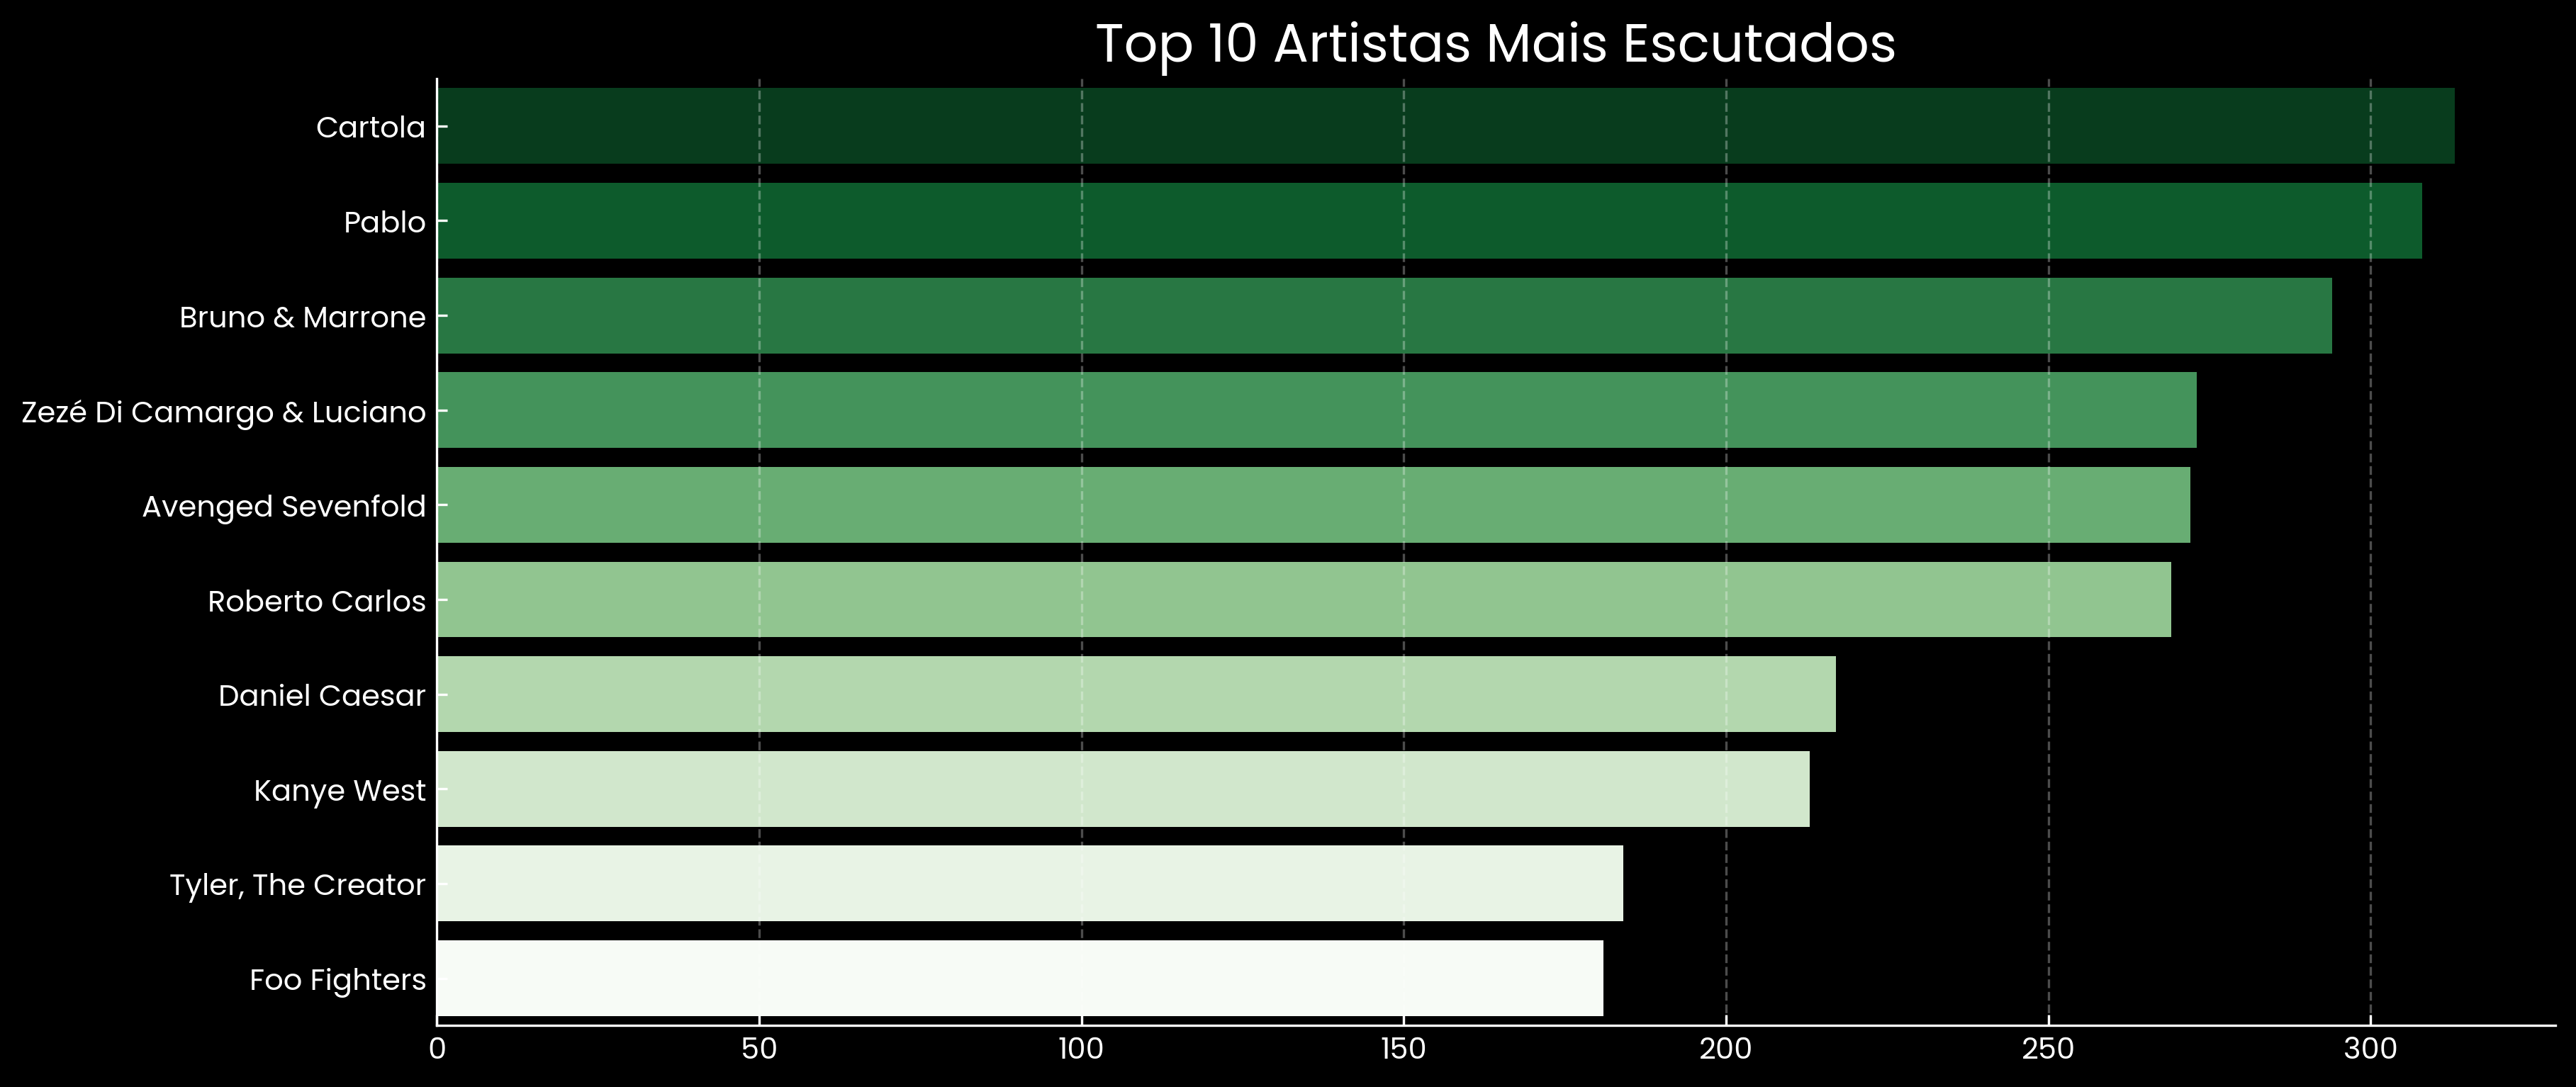

In [15]:

fig, ax = plt.subplots(figsize=(12,5), dpi=300, layout="constrained")
ax.set_title("Top 10 Artistas Mais Escutados", size=18)
sns.barplot(x=fav_artists_count["count"], y=fav_artists_count["artist_name"], palette="Greens_r", hue=fav_artists_count.index)
sns.despine()
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(direction="in")

ax.grid(axis='x', ls="--", alpha=0.3)
ax.legend().remove()
fig.savefig("Q1.png", dpi=600, bbox_inches="tight")
plt.show()
    

## 2. Quanto tempo de música eu escutei mensalmente?

In [6]:
df["minPlayed"] = (df["ms_played"] / 1_000 / 60).round(2)
meses = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
monthly_minutes = df[["minPlayed", "month"]].groupby("month").sum().reset_index()


In [7]:
monthly_minutes

,month,minPlayed
0,1,2572.51
1,2,2332.31
2,3,2273.88
3,4,3272.33
4,5,3237.26
5,6,2915.19
6,7,2413.95
7,8,3962.24
8,9,4138.17
9,10,3475.37


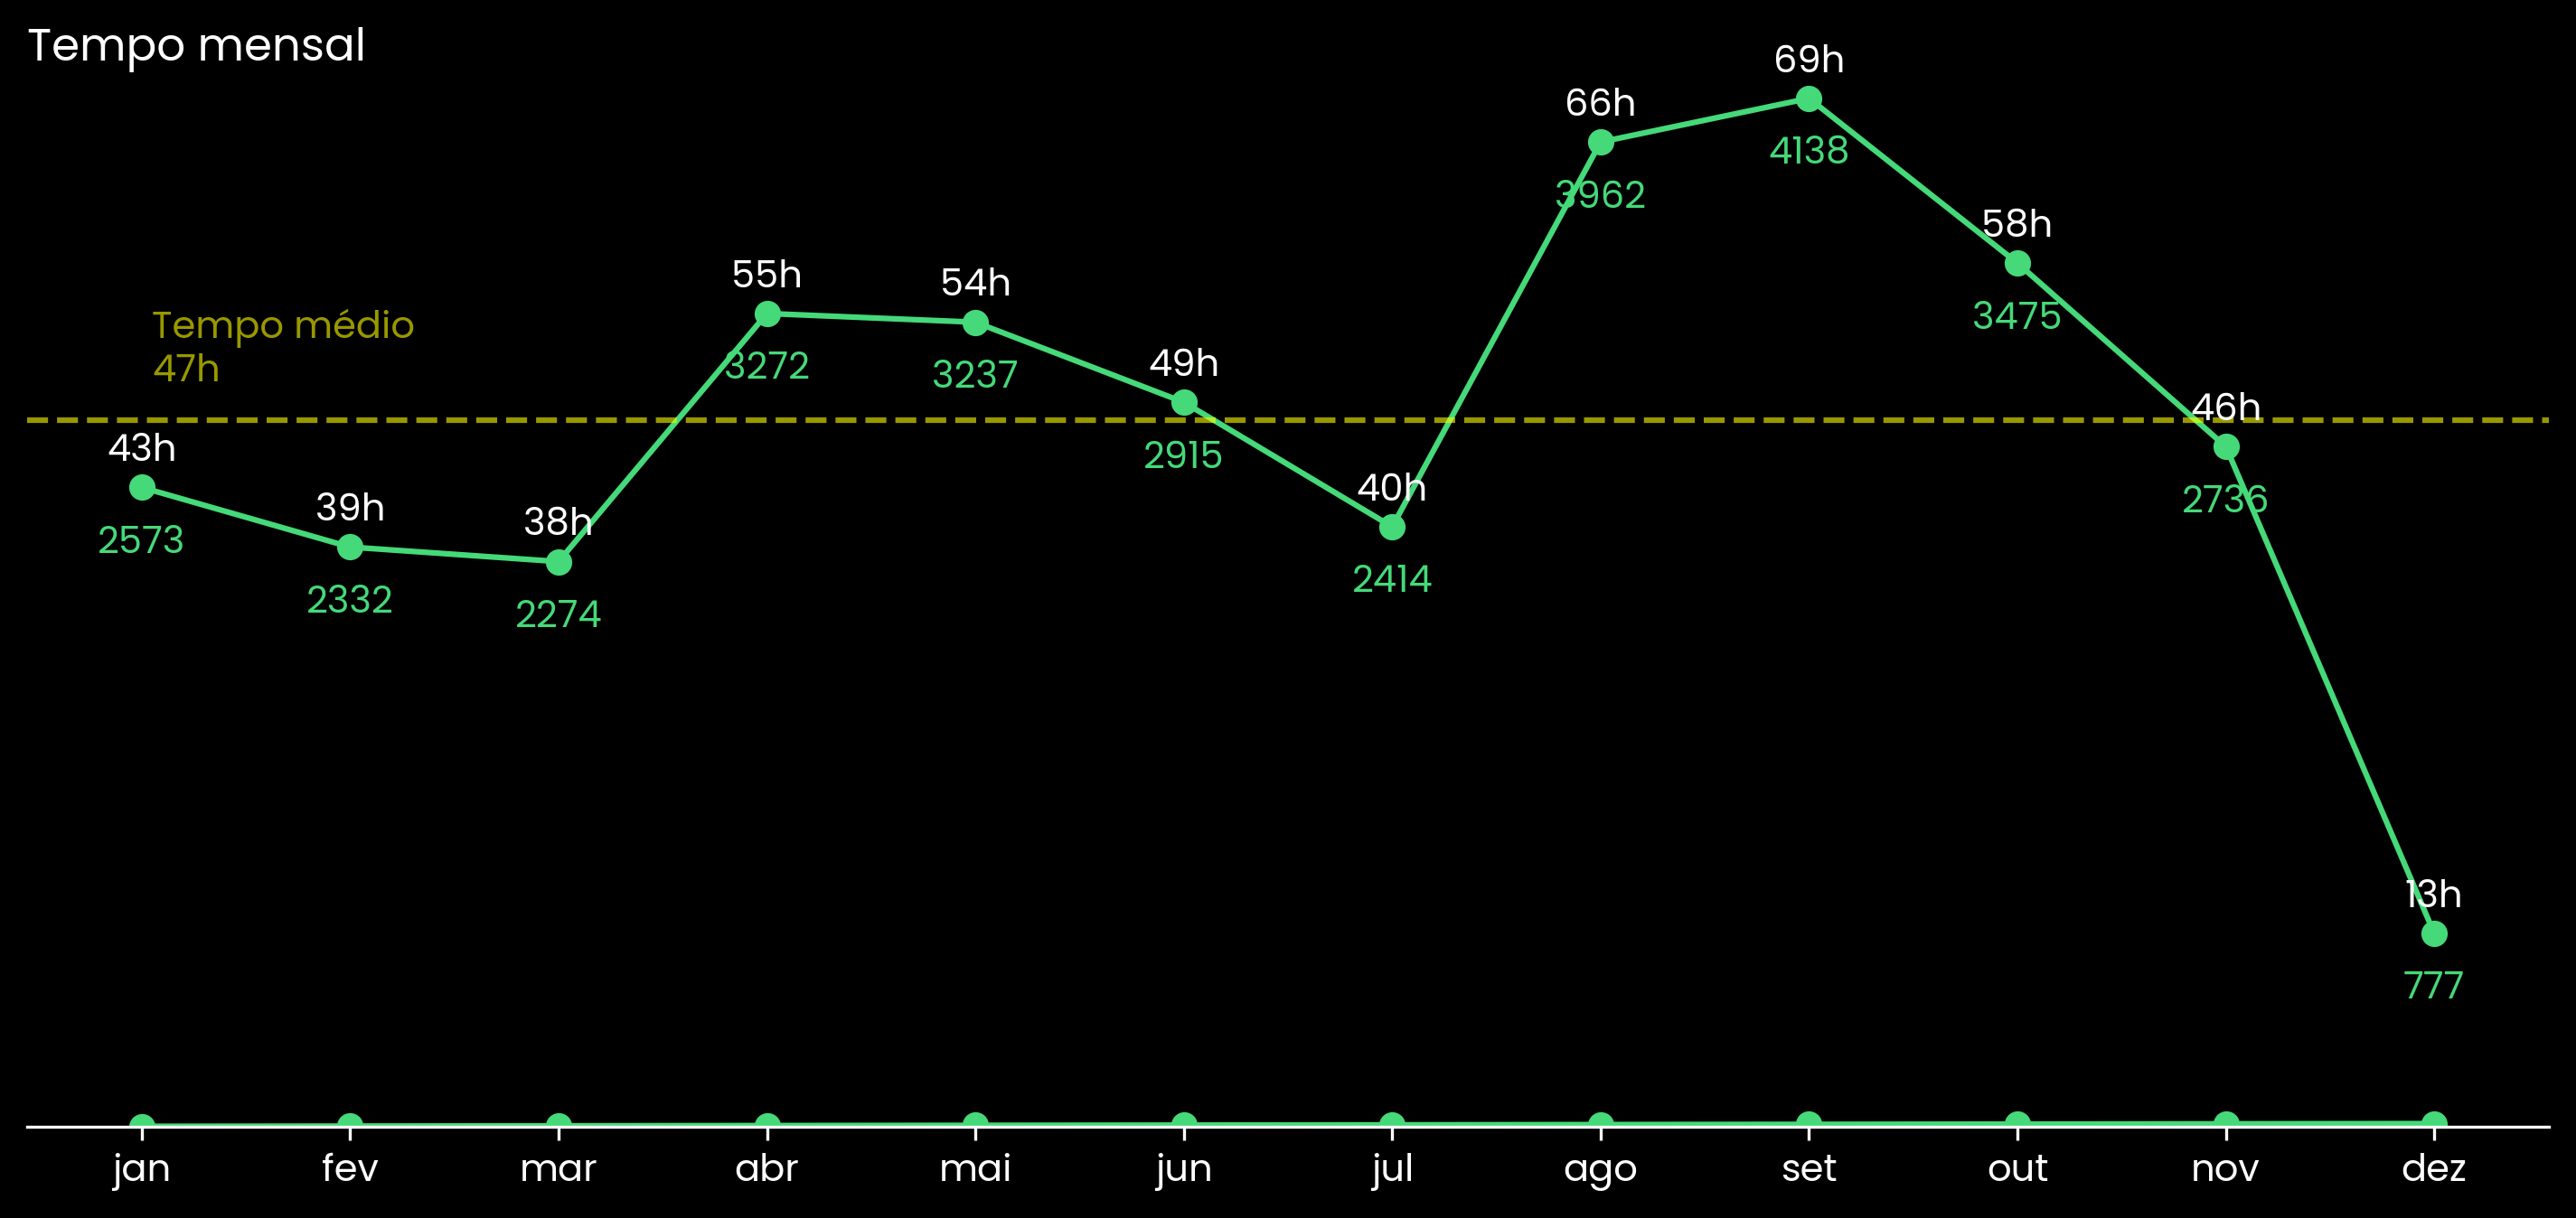

In [24]:

fig, ax = plt.subplots(figsize=(12,5), dpi=300)
ax.set_title("Tempo mensal", loc="left")
ax.set_ylim([0, 4200])
ax.plot(monthly_minutes, marker="o", color="#45d979")
ax.set_xticks(monthly_minutes.index)
ax.set_xticklabels(meses)
sns.despine(ax=ax, left=True)
ax.set_yticks([])
ax.tick_params(axis="y", length=0)
for x, y in zip(monthly_minutes.index, monthly_minutes["minPlayed"]):
    ax.text(x, y-150, f"{y:.0f}", color="#45d979", ha="center", va="top", fontsize=10)
    ax.text(x, y+220, f"{y/60:.0f}h", color="white", ha="center", va="top", fontsize=10)
tempo_medio_mensal = monthly_minutes["minPlayed"].mean()    
ax.axhline(tempo_medio_mensal, color="yellow", ls='--', alpha=0.6)
ax.text(x=0.05, y=3000, s=f"Tempo médio\n{(tempo_medio_mensal/60):.0f}h", color="yellow", alpha=0.6)
fig.savefig("Q2.png", dpi=600, bbox_inches="tight")
plt.show()


## 3. Em que dias da semana eu mais escuto música?

In [9]:
weekday_count = df.weekday.value_counts().sort_index()


In [10]:
weekday_count.reset_index()

,weekday,count
0,0,2589
1,1,2639
2,2,2340
3,3,2722
4,4,2019
5,5,1601
6,6,1229


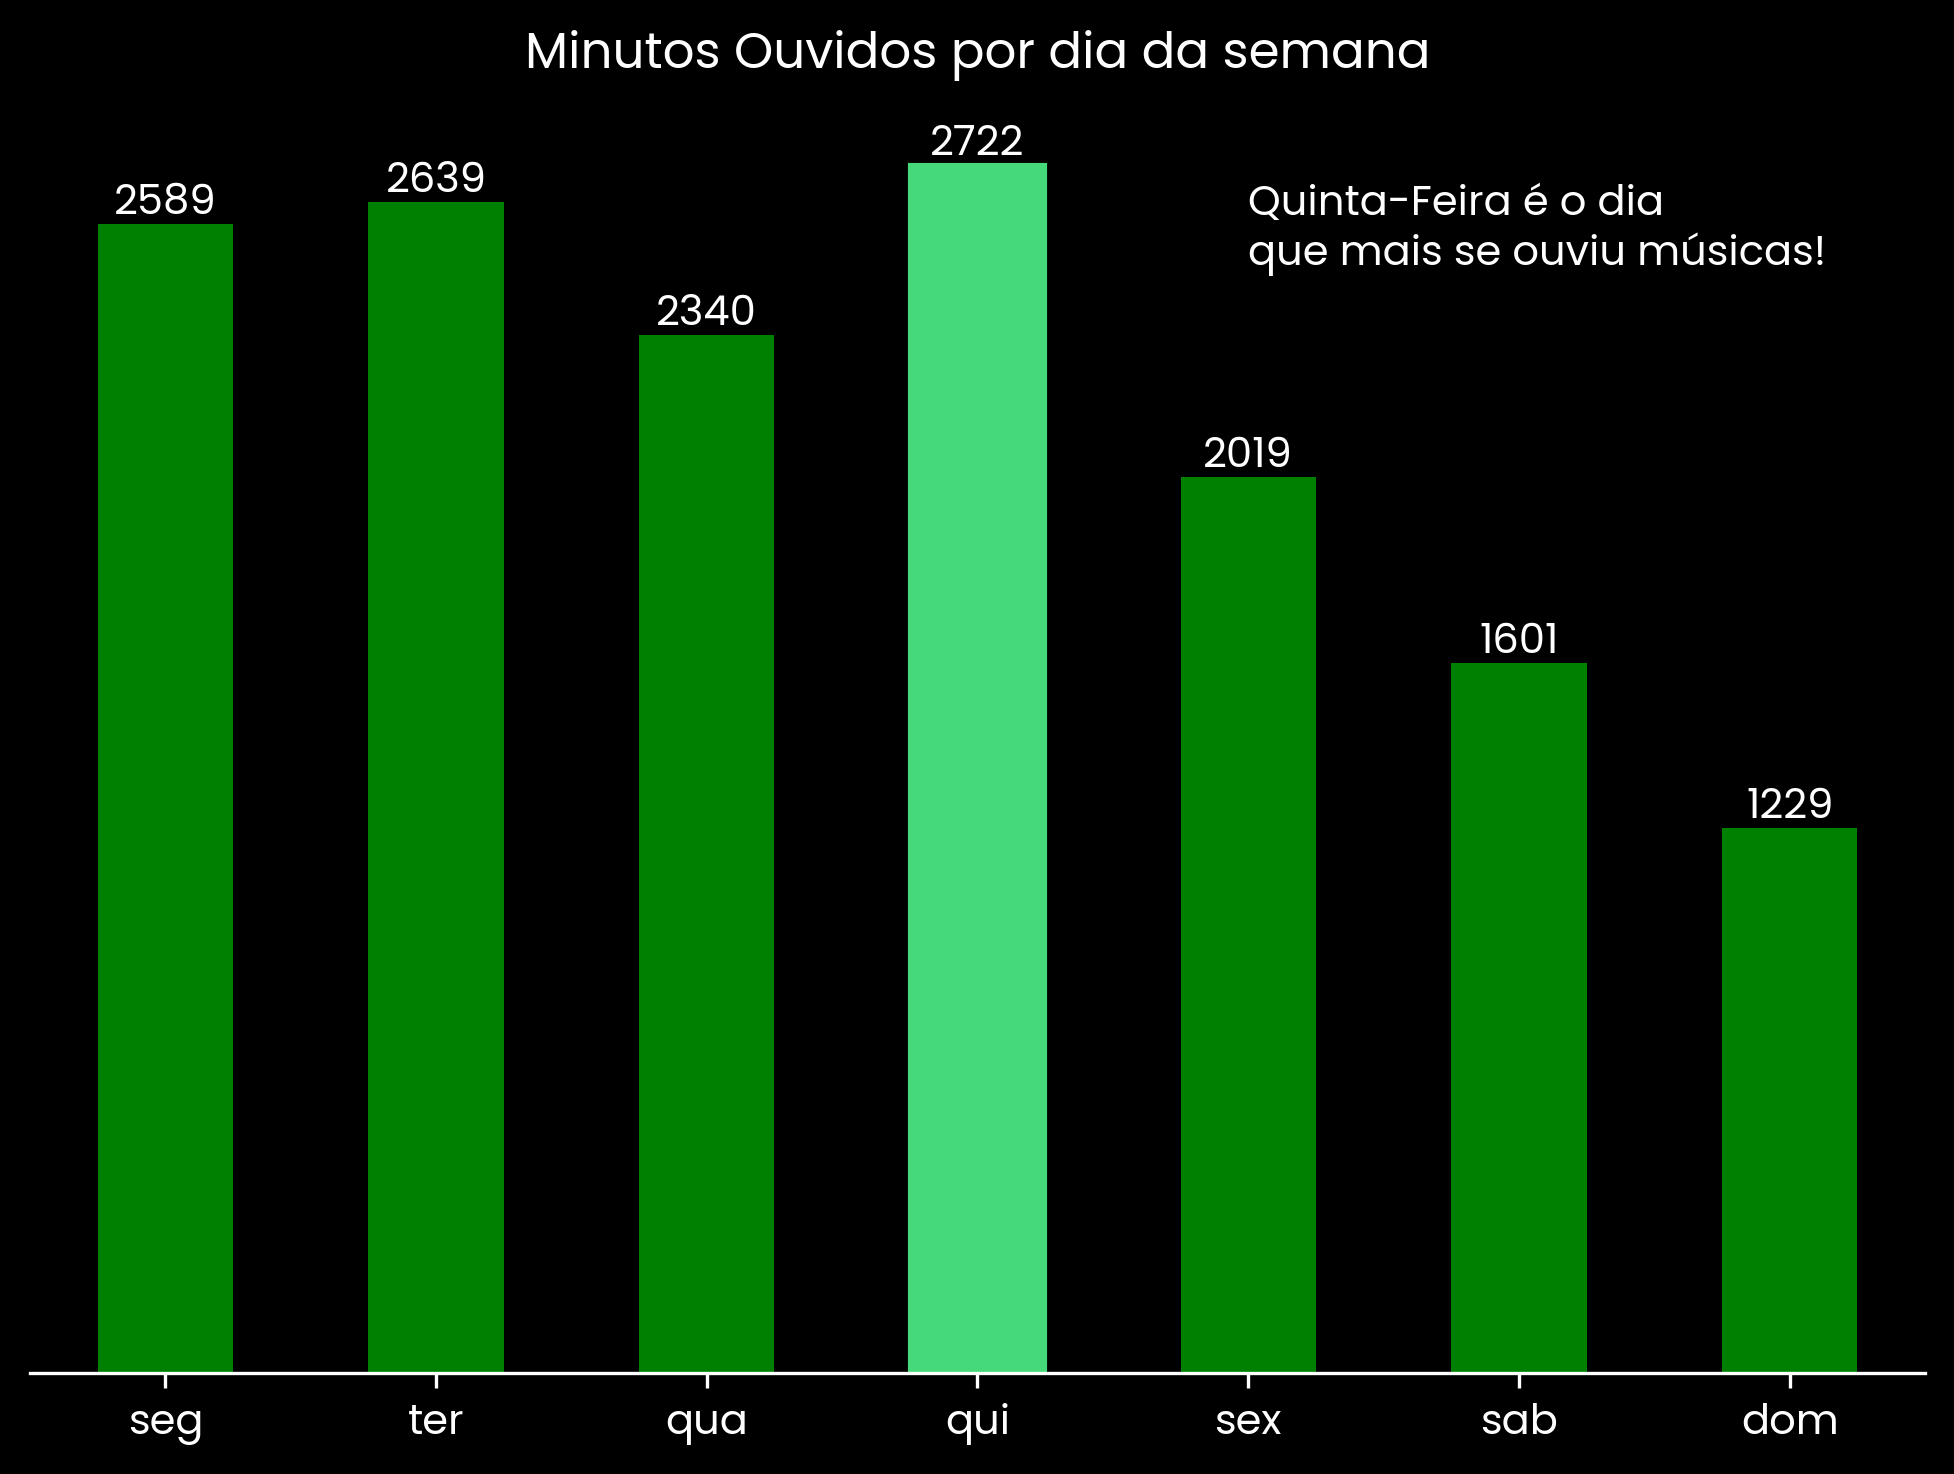

In [17]:
#  0=segunda ... 6=domingo
fig, ax = plt.subplots(dpi=300, layout="constrained")
fig.suptitle("Minutos Ouvidos por dia da semana")
weekday_count.plot(kind="bar", xlabel="",ax=ax, color="green")
ax.set_xticks(np.arange(7))
ax.set_xticklabels(["seg", "ter", "qua","qui", "sex", "sab", "dom"])
ax.tick_params(axis="x", rotation=0)

for bar in ax.containers: 
    ax.bar_label(bar)

for i, bar in enumerate(ax.containers[0]):
    if i == 3:
        bar.set_color("#45d979")
ax.set_yticks([])
sns.despine(ax=ax, left=True)
ax.text(x=4, y=2500, s="Quinta-Feira é o dia\nque mais se ouviu músicas!")
fig.savefig("Q3.png", dpi=600, bbox_inches="tight")
plt.show()

## 4. Existe preferência de horário? Pela manhã, tarde ou noite?

In [12]:
df["ts"] = pd.to_datetime(df["ts"])
df["hour"] = df["ts"].dt.hour
df.head()

,ts,platform,ms_played,track_name,artist_name,album,reason_start,reason_end,shuffle,skipped,year,month,weekday,day,time,minPlayed,hour
0,2025-01-01 19:40:17+00:00,android,31120,No Xirizal do Oscar Frota,Marcos Messias,Corno Cupim,clickrow,logout,False,False,2025,1,2,1,19:40:17,0.52,19
1,2025-01-01 21:04:11+00:00,windows,248807,White Ferrari,Frank Ocean,Blonde,playbtn,endplay,False,True,2025,1,2,1,21:04:11,4.15,21
2,2025-01-01 21:06:24+00:00,windows,132160,Beanie,Chezile,Beanie,trackdone,trackdone,False,False,2025,1,2,1,21:06:24,2.20,21
3,2025-01-01 21:09:29+00:00,windows,184516,Pink + White,Frank Ocean,Blonde,trackdone,trackdone,False,False,2025,1,2,1,21:09:29,3.08,21
4,2025-01-01 21:11:43+00:00,windows,133762,Yebba’s Heartbreak,Drake,Certified Lover Boy,trackdone,trackdone,False,False,2025,1,2,1,21:11:43,2.23,21


In [13]:
criterios = [
     df.hour < 12, 
    (df.hour >= 12) & (df.hour < 18),
    df.hour >= 18
]
turnos = ["manhã", "tarde", "noite"]

df["turno"] = np.select(condlist=criterios, choicelist=turnos)
print(df.turno)


0        noite
1        noite
2        noite
3        noite
4        noite
         ...  
15134    manhã
15135    manhã
15136    manhã
15137    manhã
15138    manhã
Name: turno, Length: 15139, dtype: object


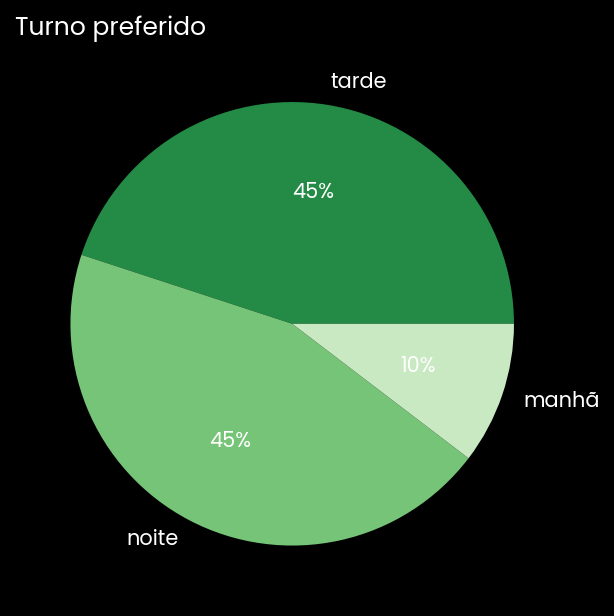

In [18]:
turno_proportion = (df.turno.value_counts(normalize=True) * 100)
greens_pie = sns.color_palette(palette="Greens_r", n_colors=3)

fig, ax = plt.subplots(dpi=150)
ax.set_title("Turno preferido", fontdict=dict(weight="bold"), loc="left")
ax.pie(turno_proportion, labels=turno_proportion.index, colors=greens_pie,autopct="%1.f%%")
fig.savefig("Q4.png", dpi=600, bbox_inches="tight")
plt.show()